# The Intelligence Battle: Human Expert vs. Evolutionary Tuning & Neuro-Fuzzy

Notebook ini mengimplementasikan dan membandingkan tiga pendekatan dalam merancang sistem cerdas untuk prediksi risiko diabetes, yaitu:

* **Fuzzy Inference System (FIS)** berbasis intuisi manusia (Human Expert)
* **Evolutionary Tuning** menggunakan Genetic Algorithm (GA)
* **Neuro-Fuzzy / Artificial Neural Networks (ANN)** untuk optimasi berbasis data

Studi kasus yang digunakan adalah **prediksi diabetes** menggunakan *Pima Indians Diabetes Database*, dengan tujuan untuk menganalisis bagaimana performa sistem yang dirancang secara manual dibandingkan dengan sistem yang dioptimasi oleh mesin.

Dataset yang digunakan berasal dari **UCI Machine Learning Repository** dan diakses melalui Kaggle pada tautan berikut:
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Melalui notebook ini, hal utama yang dilakukan:

1. Perancangan Membership Function (MF) dan rule secara manual
2. Optimasi parameter MF menggunakan GA
3. Pendekatan pembelajaran menggunakan ANN
4. Analisis komparatif performa dan interpretabilitas masing-masing metode

---

## Anggota Kelompok:

* Lukas Austin - 140810230011
* Orlando Bloem Sutono - 140810230057
* Rynad Arkansyah Gunawan - 140810230079

---

## 0. Install & Import Dependencies

In [ ]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["scikit-fuzzy", "torch", "deap"]:
    install(pkg)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json
import pickle
import random
from deap import base, creator, tools, algorithms
import copy

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
random.seed(SEED)

print("All dependencies loaded.")

All dependencies loaded.


---

## 1. Pilih Studi Kasus

### Prediksi Risiko Diabetes

Diabetes mellitus adalah kondisi kronis yang ditandai dengan kadar glukosa darah tinggi akibat gangguan produksi atau kerja insulin. Deteksi dini sangat krusial untuk mencegah komplikasi serius seperti penyakit jantung, gagal ginjal, dan kebutaan.

Prediksi diabetes merupakan **masalah pengambilan keputusan** karena:

1. **Input bersifat kontinu dan ambigu** — nilai seperti glukosa 140 mg/dL berada di zona abu-abu antara normal dan berisiko; tidak ada batas biner yang tegas.
2. **Multifaktor** — keputusan melibatkan kombinasi beberapa indikator medis (kadar glukosa, BMI, usia, riwayat keluarga, dll.) yang saling berinteraksi.
3. **Ketidakpastian klinis** — tidak semua pasien dengan nilai abnormal langsung positif diabetes; ada variasi individual yang signifikan.
4. **Trade-off risiko** — false negative (melewatkan pasien positif) jauh lebih berbahaya dari false positive, sehingga threshold keputusan perlu dikalibrasi dengan cermat.

Kombinasi karakteristik ini menjadikan prediksi diabetes sebagai kandidat ideal untuk pendekatan **Fuzzy Logic**, yang secara alami menangani ketidakpastian dan gradasi, serta perbandingan dengan metode berbasis data seperti GA dan ANFIS.

---

## 2. Data Preparation

In [ ]:
df = pd.read_csv("diabetes.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Analisis Korelasi

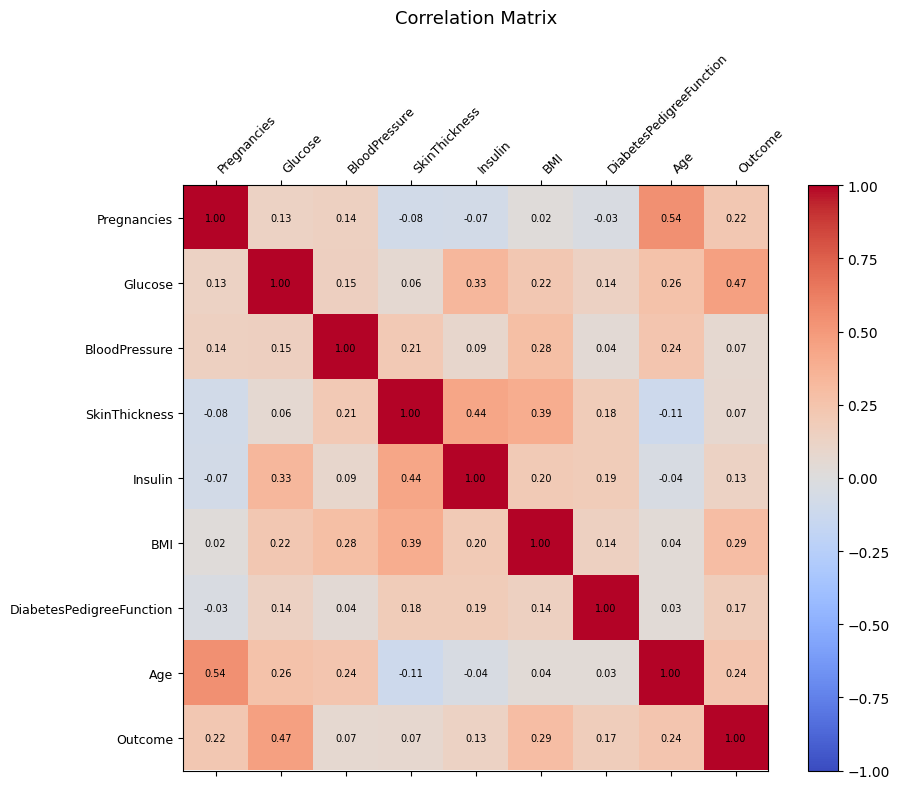

In [ ]:
import matplotlib.colors as mcolors

corr = df.corr()
fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
fig.colorbar(cax)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="left", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
ax.set_title("Correlation Matrix", pad=20, fontsize=13)
plt.tight_layout()
plt.show()

### Penanganan Nilai 0 Sebagai Missing Value

Beberapa fitur memiliki nilai `0` yang secara medis tidak valid:

- **Glucose**: Kadar glukosa plasma 0 tidak mungkin terjadi pada manusia hidup.
- **BloodPressure**: Tekanan darah diastolik 0 secara klinis berarti kematian.
- **SkinThickness**: Ketebalan lipatan kulit 0 tidak realistis untuk pengukuran tubuh.
- **Insulin**: Nilai 0 sangat banyak dan kemungkinan besar adalah data yang tidak tercatat.
- **BMI**: BMI 0 tidak mungkin terjadi pada manusia hidup.

Fitur `Pregnancies` dan `Age` dibiarkan karena 0 kehamilan secara logika valid. `DiabetesPedigreeFunction` tidak memiliki nilai 0.

Strategi imputasi: nilai 0 diganti dengan **median kelompok berdasarkan Outcome** agar mempertahankan distribusi yang relevan secara klinis.

In [ ]:
ZERO_INVALID_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in ZERO_INVALID_COLS:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zero values ({zero_count/len(df)*100:.1f}%)")

Glucose: 5 zero values (0.7%)
BloodPressure: 35 zero values (4.6%)
SkinThickness: 227 zero values (29.6%)
Insulin: 374 zero values (48.7%)
BMI: 11 zero values (1.4%)


In [ ]:
df_clean = df.copy()

for col in ZERO_INVALID_COLS:
    df_clean[col] = df_clean[col].replace(0, np.nan)
    medians = df_clean.groupby("Outcome")[col].transform("median")
    df_clean[col] = df_clean[col].fillna(medians)

print("Missing values after imputation:")
print(df_clean.isnull().sum())
df_clean.describe()

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Train-Test Split

In [ ]:
FEATURES = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
TARGET = "Outcome"

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = MinMaxScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Class distribution (train): {np.bincount(y_train)}")
print(f"Class distribution (test):  {np.bincount(y_test)}")

Train size: 614 | Test size: 154
Class distribution (train): [400 214]
Class distribution (test):  [100  54]


---

# Tahap 1 — Human Intuition: Manual FIS

## 3. Implementasi FIS Manual

Sistem inferensi fuzzy dirancang menggunakan metode **Mamdani** dengan 8 variabel input dan 1 variabel output. Setiap variabel input dibagi menjadi 3 kategori linguistik: `low`, `medium`, `high`. Parameter membership function (MF) ditentukan berdasarkan pengetahuan domain medis dan statistik deskriptif dataset.

| Fitur | Low | Medium | High |
|---|---|---|---|
| Pregnancies | [0, 0, 3, 6] | [3, 6, 9] | [6, 9, 17] |
| Glucose | [0, 0, 100, 125] | [100, 125, 150] | [125, 150, 200] |
| BloodPressure | [0, 0, 60, 80] | [60, 80, 100] | [80, 100, 130] |
| SkinThickness | [0, 0, 20, 35] | [20, 35, 50] | [35, 50, 100] |
| Insulin | [0, 0, 100, 200] | [100, 200, 300] | [200, 300, 850] |
| BMI | [0, 0, 25, 30] | [25, 30, 35] | [30, 35, 70] |
| DiabetesPedigreeFunction | [0, 0, 0.3, 0.6] | [0.3, 0.6, 1.0] | [0.6, 1.0, 2.5] |
| Age | [0, 0, 25, 40] | [25, 40, 55] | [40, 55, 100] |

In [ ]:
MANUAL_MF_PARAMS = {
    "Pregnancies": {
        "range": [0, 18],
        "low":    [0, 0, 3, 6],
        "medium": [3, 6, 9],
        "high":   [6, 9, 17]
    },
    "Glucose": {
        "range": [0, 200],
        "low":    [0, 0, 100, 125],
        "medium": [100, 125, 150],
        "high":   [125, 150, 200]
    },
    "BloodPressure": {
        "range": [0, 130],
        "low":    [0, 0, 60, 80],
        "medium": [60, 80, 100],
        "high":   [80, 100, 130]
    },
    "SkinThickness": {
        "range": [0, 100],
        "low":    [0, 0, 20, 35],
        "medium": [20, 35, 50],
        "high":   [35, 50, 100]
    },
    "Insulin": {
        "range": [0, 850],
        "low":    [0, 0, 100, 200],
        "medium": [100, 200, 300],
        "high":   [200, 300, 850]
    },
    "BMI": {
        "range": [0, 70],
        "low":    [0, 0, 25, 30],
        "medium": [25, 30, 35],
        "high":   [30, 35, 70]
    },
    "DiabetesPedigreeFunction": {
        "range": [0, 2.5],
        "low":    [0, 0, 0.3, 0.6],
        "medium": [0.3, 0.6, 1.0],
        "high":   [0.6, 1.0, 2.5]
    },
    "Age": {
        "range": [0, 100],
        "low":    [0, 0, 25, 40],
        "medium": [25, 40, 55],
        "high":   [40, 55, 100]
    }
}

print("Manual MF parameters defined.")

Manual MF parameters defined.


In [ ]:
def build_fis_manual(mf_params):
    antecedents = {}
    for feat, p in mf_params.items():
        lo, hi = p["range"]
        universe = np.linspace(lo, hi, 500)
        ant = ctrl.Antecedent(universe, feat)
        low_p = p["low"]
        med_p = p["medium"]
        high_p = p["high"]
        if len(low_p) == 4:
            ant["low"] = fuzz.trapmf(universe, low_p)
        else:
            ant["low"] = fuzz.trimf(universe, low_p)
        ant["medium"] = fuzz.trimf(universe, med_p)
        if len(high_p) == 4:
            ant["high"] = fuzz.trapmf(universe, high_p)
        else:
            ant["high"] = fuzz.trimf(universe, high_p)
        antecedents[feat] = ant

    risk_universe = np.linspace(0, 1, 500)
    risk = ctrl.Consequent(risk_universe, "risk")
    risk["low"]    = fuzz.trapmf(risk_universe, [0, 0, 0.2, 0.4])
    risk["medium"] = fuzz.trimf(risk_universe, [0.3, 0.5, 0.7])
    risk["high"]   = fuzz.trapmf(risk_universe, [0.6, 0.8, 1.0, 1.0])
    risk.defuzzify_method = "centroid"

    p = antecedents
    rules = [
        ctrl.Rule(p["Glucose"]["high"] & p["BMI"]["high"],                   risk["high"]),
        ctrl.Rule(p["Glucose"]["high"] & p["Age"]["high"],                    risk["high"]),
        ctrl.Rule(p["Glucose"]["high"] & p["Insulin"]["high"],                risk["high"]),
        ctrl.Rule(p["Glucose"]["high"] & p["DiabetesPedigreeFunction"]["high"], risk["high"]),
        ctrl.Rule(p["Glucose"]["medium"] & p["BMI"]["high"] & p["Age"]["high"], risk["high"]),
        ctrl.Rule(p["Glucose"]["medium"] & p["BMI"]["high"],                   risk["medium"]),
        ctrl.Rule(p["Glucose"]["medium"] & p["Pregnancies"]["high"],           risk["medium"]),
        ctrl.Rule(p["Glucose"]["medium"] & p["DiabetesPedigreeFunction"]["medium"], risk["medium"]),
        ctrl.Rule(p["Glucose"]["low"]  & p["BMI"]["low"],                     risk["low"]),
        ctrl.Rule(p["Glucose"]["low"]  & p["Age"]["low"],                     risk["low"]),
        ctrl.Rule(p["BMI"]["high"] & p["SkinThickness"]["high"],               risk["medium"]),
        ctrl.Rule(p["BMI"]["low"]  & p["Glucose"]["low"],                     risk["low"]),
        ctrl.Rule(p["Pregnancies"]["high"] & p["Glucose"]["medium"],           risk["medium"]),
        ctrl.Rule(p["Age"]["high"] & p["BMI"]["medium"],                      risk["medium"]),
        ctrl.Rule(p["DiabetesPedigreeFunction"]["high"] & p["Glucose"]["medium"], risk["high"]),
        ctrl.Rule(p["Insulin"]["high"] & p["Glucose"]["medium"],               risk["medium"]),
        ctrl.Rule(p["BloodPressure"]["high"] & p["BMI"]["high"],               risk["medium"]),
        ctrl.Rule(p["Glucose"]["low"] & p["BMI"]["medium"] & p["Age"]["low"],  risk["low"]),
    ]

    system = ctrl.ControlSystem(rules)
    return ctrl.ControlSystemSimulation(system), antecedents, risk


fis_sim, fis_antecedents, fis_risk = build_fis_manual(MANUAL_MF_PARAMS)
# RuleOrderGenerator tidak mendukung len()
n_rules = sum(1 for _ in fis_sim.ctrl.rules)
print(f"FIS Manual built with {n_rules} rules.")

FIS Manual built with 18 rules.


In [ ]:
def fis_predict(sim, X, features, threshold=0.45):
    preds = []
    scores = []
    for row in X:
        try:
            for i, feat in enumerate(features):
                lo, hi = MANUAL_MF_PARAMS[feat]["range"]
                val = np.clip(row[i], lo + 1e-6, hi - 1e-6)
                sim.input[feat] = val
            sim.compute()
            score = sim.output["risk"]
        except Exception:
            score = 0.5
        scores.append(score)
        preds.append(1 if score >= threshold else 0)
    return np.array(preds), np.array(scores)


y_pred_fis, scores_fis = fis_predict(fis_sim, X_test, FEATURES)
acc_fis = accuracy_score(y_test, y_pred_fis)
print(f"FIS Manual Accuracy: {acc_fis:.4f}")
print(classification_report(y_test, y_pred_fis, target_names=["No Diabetes", "Diabetes"]))

FIS Manual Accuracy: 0.6818
              precision    recall  f1-score   support

 No Diabetes       0.87      0.60      0.71       100
    Diabetes       0.53      0.83      0.65        54

    accuracy                           0.68       154
   macro avg       0.70      0.72      0.68       154
weighted avg       0.75      0.68      0.69       154



---

## 4. Visualisasi FIS Manual

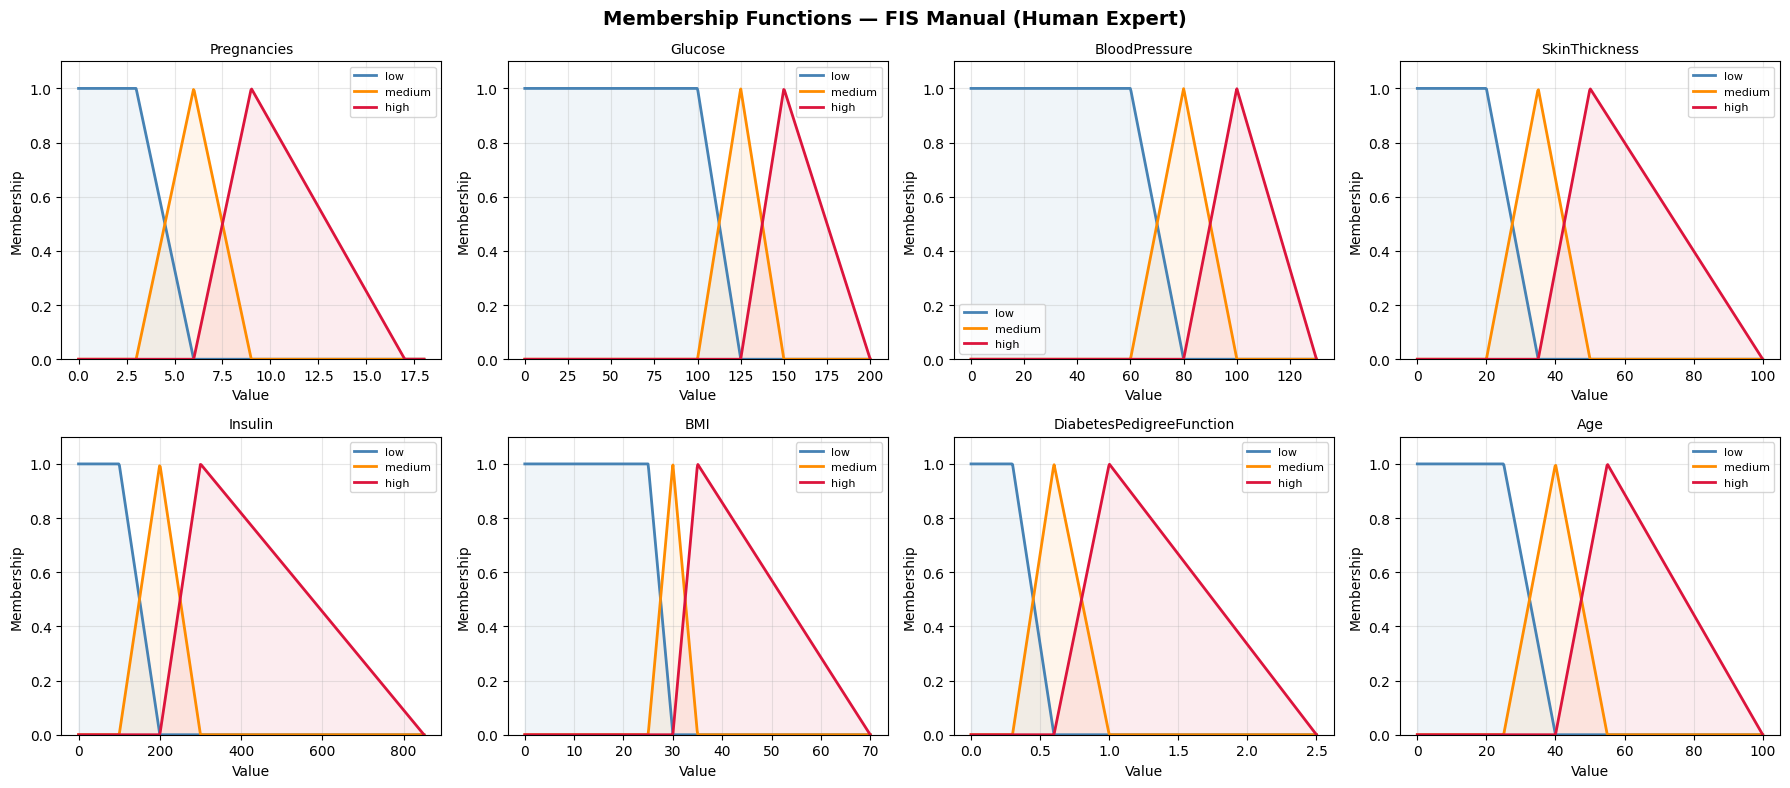

In [ ]:
def plot_mf_for_feature(feat, params, ax, title_suffix=""):
    lo, hi = params["range"]
    x = np.linspace(lo, hi, 500)
    colors = {"low": "steelblue", "medium": "darkorange", "high": "crimson"}
    for label in ["low", "medium", "high"]:
        p = params[label]
        mf = fuzz.trapmf(x, p) if len(p) == 4 else fuzz.trimf(x, p)
        ax.plot(x, mf, label=label, color=colors[label], linewidth=2)
        ax.fill_between(x, 0, mf, alpha=0.08, color=colors[label])
    ax.set_title(f"{feat}{title_suffix}", fontsize=10)
    ax.set_xlabel("Value")
    ax.set_ylabel("Membership")
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Membership Functions — FIS Manual (Human Expert)", fontsize=14, fontweight="bold")
for ax, feat in zip(axes.flatten(), FEATURES):
    plot_mf_for_feature(feat, MANUAL_MF_PARAMS[feat], ax)
plt.tight_layout()
plt.show()

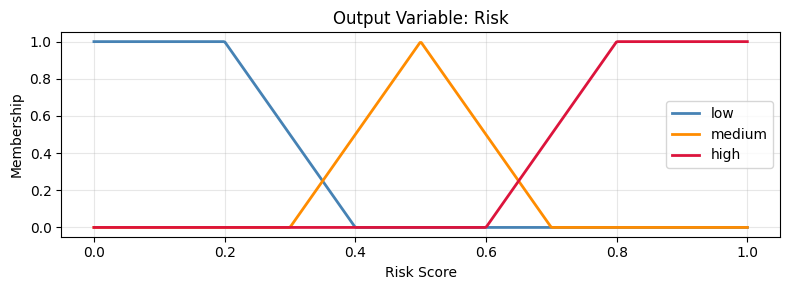

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3))
x_risk = np.linspace(0, 1, 500)
mf_low    = fuzz.trapmf(x_risk, [0, 0, 0.2, 0.4])
mf_med    = fuzz.trimf(x_risk, [0.3, 0.5, 0.7])
mf_high   = fuzz.trapmf(x_risk, [0.6, 0.8, 1.0, 1.0])
ax.plot(x_risk, mf_low,  label="low",    color="steelblue", linewidth=2)
ax.plot(x_risk, mf_med,  label="medium", color="darkorange", linewidth=2)
ax.plot(x_risk, mf_high, label="high",   color="crimson", linewidth=2)
ax.set_title("Output Variable: Risk", fontsize=12)
ax.set_xlabel("Risk Score")
ax.set_ylabel("Membership")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
sample_idx = 0
sample = X_test[sample_idx]
print("Sample input:")
for i, f in enumerate(FEATURES):
    print(f"  {f}: {sample[i]:.2f}")
print(f"\nTrue label: {y_test[sample_idx]}")
print(f"FIS risk score: {scores_fis[sample_idx]:.4f}")
print(f"FIS prediction: {y_pred_fis[sample_idx]}")

Sample input:
  Pregnancies: 7.00
  Glucose: 159.00
  BloodPressure: 64.00
  SkinThickness: 27.00
  Insulin: 102.50
  BMI: 27.40
  DiabetesPedigreeFunction: 0.29
  Age: 40.00

True label: 0
FIS risk score: 0.6498
FIS prediction: 1


---

# Tahap 2 — Evolutionary Tuning: Genetic Algorithm

## 5. Implementasi Genetic Algorithm

GA digunakan untuk mengoptimasi **parameter numerik dari setiap membership function** (nilai titik sudut trapesium/segitiga). Setiap individu dalam populasi merepresentasikan satu set lengkap parameter MF untuk seluruh 8 fitur.

Konfigurasi:
- **Population Size**: 10
- **Generations**: 5
- **Crossover**: Two-point, prob = 0.7
- **Mutation**: Gaussian perturbation, prob = 0.2
- **Fitness**: Akurasi pada data training

In [ ]:
def params_to_chromosome(mf_params):
    """Flatten semua parameter MF ke dalam satu list (chromosome)."""
    chrom = []
    for feat in FEATURES:
        p = mf_params[feat]
        chrom.extend(p["low"])
        chrom.extend(p["medium"])
        chrom.extend(p["high"])
    return chrom


def chromosome_to_params(chrom):
    """Rekonstruksi dict MF parameter dari chromosome."""
    params = {}
    idx = 0
    for feat in FEATURES:
        orig = MANUAL_MF_PARAMS[feat]
        lo_len  = len(orig["low"])
        med_len = len(orig["medium"])
        hi_len  = len(orig["high"])
        params[feat] = {
            "range": orig["range"],
            "low":    list(chrom[idx:idx + lo_len]),
            "medium": list(chrom[idx + lo_len:idx + lo_len + med_len]),
            "high":   list(chrom[idx + lo_len + med_len:idx + lo_len + med_len + hi_len]),
        }
        idx += lo_len + med_len + hi_len
    return params


def clamp_params(params):
    """Pastikan parameter MF monoton dan dalam range."""
    clamped = {}
    for feat, p in params.items():
        lo, hi = p["range"]
        span = hi - lo
        new_p = {"range": p["range"]}
        for key in ["low", "medium", "high"]:
            vals = np.clip(p[key], lo, hi)
            vals = np.sort(vals)
            new_p[key] = list(vals)
        clamped[feat] = new_p
    return clamped


def evaluate_chromosome(chrom, X_eval, y_eval, n_samples=100):
    """Fitness function: akurasi FIS pada subset data."""
    params = clamp_params(chromosome_to_params(chrom))
    try:
        sim, _, _ = build_fis_manual(params)
        idx = np.random.choice(len(X_eval), min(n_samples, len(X_eval)), replace=False)
        preds, _ = fis_predict(sim, X_eval[idx], FEATURES)
        acc = accuracy_score(y_eval[idx], preds)
    except Exception:
        acc = 0.0
    return (acc,)


BASE_CHROM = params_to_chromosome(MANUAL_MF_PARAMS)
CHROM_LEN  = len(BASE_CHROM)
print(f"Chromosome length: {CHROM_LEN} genes")

Chromosome length: 80 genes


In [ ]:
if "FitnessMax" in creator.__dict__:
    del creator.FitnessMax
if "Individual" in creator.__dict__:
    del creator.Individual

creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()

def init_gene(base_val):
    return base_val + np.random.normal(0, 3)

def init_individual():
    ind = [init_gene(v) for v in BASE_CHROM]
    return creator.Individual(ind)

toolbox.register("individual", init_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate",   evaluate_chromosome, X_eval=X_train, y_eval=y_train)
toolbox.register("mate",       tools.cxTwoPoint)
toolbox.register("mutate",     tools.mutGaussian, mu=0, sigma=2, indpb=0.15)
toolbox.register("select",     tools.selTournament, tournsize=3)

POP_SIZE   = 10
N_GEN      = 5
CXPB       = 0.7
MUTPB      = 0.2

print(f"GA config: pop={POP_SIZE}, gen={N_GEN}, cxpb={CXPB}, mutpb={MUTPB}")

GA config: pop=10, gen=5, cxpb=0.7, mutpb=0.2


In [ ]:
pop = toolbox.population(n=POP_SIZE)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max",  np.max)
stats.register("mean", np.mean)

hof = tools.HallOfFame(1)
gen_log = []

print("Starting GA optimization...")
for gen in range(N_GEN):
    offspring = algorithms.varAnd(pop, toolbox, cxpb=CXPB, mutpb=MUTPB)
    fits = list(map(toolbox.evaluate, offspring))
    for ind, fit in zip(offspring, fits):
        ind.fitness.values = fit
    pop = toolbox.select(offspring + pop, k=POP_SIZE)
    hof.update(pop)
    invalid_inds = [ind for ind in pop if not ind.fitness.valid]
    if invalid_inds:
        invalid_fits = list(map(toolbox.evaluate, invalid_inds))
        for ind, fit in zip(invalid_inds, invalid_fits):
            ind.fitness.values = fit

    fitness_vals = [ind.fitness.values[0] for ind in pop]
    record = {"max": float(np.max(fitness_vals)), "mean": float(np.mean(fitness_vals))}
    gen_log.append({"gen": gen + 1, "max": record["max"], "mean": record["mean"]})
    print(f"  Gen {gen+1:2d} | Best: {record['max']:.4f} | Mean: {record['mean']:.4f}")

best_chrom = hof[0]
GA_MF_PARAMS = clamp_params(chromosome_to_params(best_chrom))
print("\nGA optimization complete.")

Starting GA optimization...
  Gen  1 | Best: 0.7000 | Mean: 0.6530
  Gen  2 | Best: 0.7400 | Mean: 0.6990
  Gen  3 | Best: 0.7400 | Mean: 0.7160
  Gen  4 | Best: 0.7600 | Mean: 0.7280
  Gen  5 | Best: 0.7800 | Mean: 0.7580

GA optimization complete.


In [ ]:
fis_ga_sim, _, _ = build_fis_manual(GA_MF_PARAMS)
y_pred_ga, scores_ga = fis_predict(fis_ga_sim, X_test, FEATURES)
acc_ga = accuracy_score(y_test, y_pred_ga)
print(f"FIS + GA Accuracy: {acc_ga:.4f}")
print(classification_report(y_test, y_pred_ga, target_names=["No Diabetes", "Diabetes"]))

FIS + GA Accuracy: 0.6948
              precision    recall  f1-score   support

 No Diabetes       0.88      0.61      0.72       100
    Diabetes       0.54      0.85      0.66        54

    accuracy                           0.69       154
   macro avg       0.71      0.73      0.69       154
weighted avg       0.76      0.69      0.70       154



---

## 6. Visualisasi Hasil GA

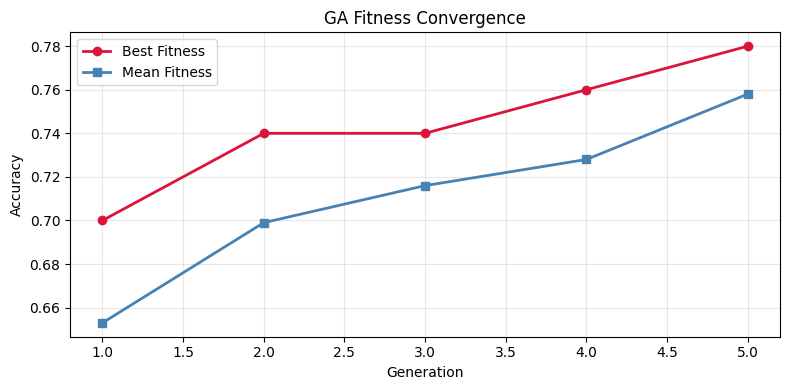

In [ ]:
gen_df = pd.DataFrame(gen_log)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gen_df["gen"], gen_df["max"],  marker="o", label="Best Fitness",  color="crimson",    linewidth=2)
ax.plot(gen_df["gen"], gen_df["mean"], marker="s", label="Mean Fitness",  color="steelblue",  linewidth=2)
ax.set_xlabel("Generation")
ax.set_ylabel("Accuracy")
ax.set_title("GA Fitness Convergence", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

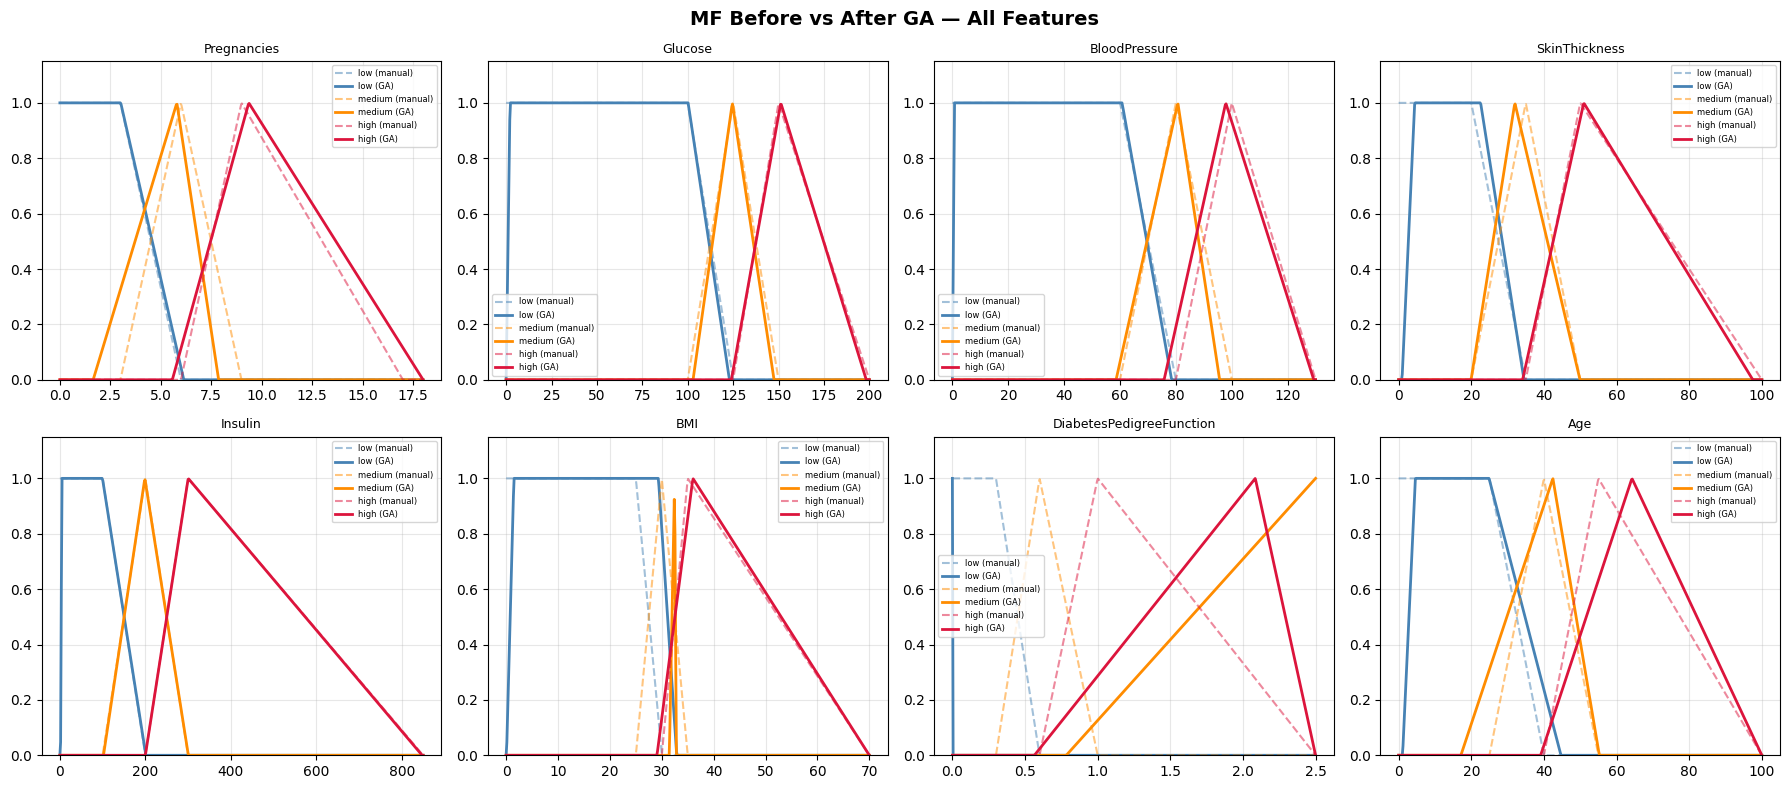

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("MF Before vs After GA — All Features", fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flatten(), FEATURES):
    orig = MANUAL_MF_PARAMS[feat]
    tuned = GA_MF_PARAMS[feat]
    lo, hi = orig["range"]
    x = np.linspace(lo, hi, 500)

    for label, color in [("low", "steelblue"), ("medium", "darkorange"), ("high", "crimson")]:
        p_orig  = orig[label]
        p_tuned = tuned[label]
        mf_orig  = fuzz.trapmf(x, p_orig)  if len(p_orig)  == 4 else fuzz.trimf(x, p_orig)
        mf_tuned = fuzz.trapmf(x, p_tuned) if len(p_tuned) == 4 else fuzz.trimf(x, p_tuned)
        ax.plot(x, mf_orig,  linestyle="--", color=color, alpha=0.5, linewidth=1.5, label=f"{label} (manual)")
        ax.plot(x, mf_tuned, linestyle="-",  color=color, linewidth=2, label=f"{label} (GA)")

    ax.set_title(feat, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

---

# Tahap 3 — ANFIS: Neuro-Fuzzy (PyTorch)

## 7. Implementasi ANFIS

ANFIS (Adaptive Neuro-Fuzzy Inference System) diimplementasikan menggunakan PyTorch dengan arsitektur berlapis yang mencerminkan 5 layer struktur ANFIS standar:

1. **Layer 1 — Fuzzification**: Setiap neuron menghitung derajat keanggotaan menggunakan fungsi Gaussian yang parameternya (`mean`, `sigma`) dapat dipelajari.
2. **Layer 2 — Rule Strength**: Mengalikan derajat keanggotaan antar fitur untuk mendapatkan firing strength tiap rule.
3. **Layer 3 — Normalization**: Menormalisasi firing strength.
4. **Layer 4 — Consequent**: Output linear per rule.
5. **Layer 5 — Aggregation**: Menjumlahkan output terbobot.

Karena 8 fitur x 3 MF menghasilkan 3^8 = 6561 rule yang tidak praktis, digunakan **pendekatan ANFIS parsial** dengan strategi *rule reduction*: setiap fitur direpresentasikan secara independen (first-order Sugeno style) dan dikombinasikan dengan layer linear.

In [ ]:
class ANFISLayer(nn.Module):
    """
    ANFIS dengan n_mf membership functions per fitur.
    Menggunakan Gaussian MF yang parameternya trainable.
    Arsitektur: Fuzzification -> Firing Strength -> Normalization -> Output
    """

    def __init__(self, n_features: int, n_mf: int = 3):
        super().__init__()
        self.n_features = n_features
        self.n_mf       = n_mf

        means_init  = torch.linspace(0.1, 0.9, n_mf).unsqueeze(0).repeat(n_features, 1)
        sigmas_init = torch.full((n_features, n_mf), 0.3)

        self.means  = nn.Parameter(means_init)
        self.sigmas = nn.Parameter(sigmas_init)

        self.output_layer = nn.Linear(n_features * n_mf, 1)

    def fuzzify(self, x: torch.Tensor) -> torch.Tensor:
        """x: (batch, features) -> (batch, features, n_mf)"""
        x_exp = x.unsqueeze(2)
        mu = torch.exp(-0.5 * ((x_exp - self.means) / (self.sigmas.abs() + 1e-6)) ** 2)
        return mu

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mu = self.fuzzify(x)
        flat = mu.view(x.size(0), -1)
        out = torch.sigmoid(self.output_layer(flat))
        return out.squeeze(1)

    def get_mf_params(self) -> dict:
        return {
            "means":  self.means.detach().numpy().tolist(),
            "sigmas": self.sigmas.detach().numpy().tolist()
        }


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
anfis_model = ANFISLayer(n_features=len(FEATURES), n_mf=3).to(DEVICE)
print(anfis_model)
print(f"\nTotal parameters: {sum(p.numel() for p in anfis_model.parameters())}")

ANFISLayer(
  (output_layer): Linear(in_features=24, out_features=1, bias=True)
)

Total parameters: 73


In [ ]:
X_tr = torch.tensor(X_train_sc, dtype=torch.float32).to(DEVICE)
y_tr = torch.tensor(y_train,    dtype=torch.float32).to(DEVICE)
X_te = torch.tensor(X_test_sc,  dtype=torch.float32).to(DEVICE)
y_te = torch.tensor(y_test,     dtype=torch.float32).to(DEVICE)

train_ds = TensorDataset(X_tr, y_tr)
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

optimizer = torch.optim.Adam(anfis_model.parameters(), lr=0.01)
criterion = nn.BCELoss()

N_EPOCHS = 100
train_losses = []

for epoch in range(1, N_EPOCHS + 1):
    anfis_model.train()
    epoch_loss = 0.0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        out  = anfis_model(xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    avg_loss = epoch_loss / len(train_ds)
    train_losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/{N_EPOCHS} | Loss: {avg_loss:.4f}")

print("\nTraining complete.")

Epoch  10/100 | Loss: 0.3284
Epoch  20/100 | Loss: 0.2982
Epoch  30/100 | Loss: 0.3064
Epoch  40/100 | Loss: 0.2947
Epoch  50/100 | Loss: 0.3111
Epoch  60/100 | Loss: 0.2911
Epoch  70/100 | Loss: 0.2858
Epoch  80/100 | Loss: 0.3019
Epoch  90/100 | Loss: 0.3579
Epoch 100/100 | Loss: 0.2953

Training complete.


In [ ]:
anfis_model.eval()
with torch.no_grad():
    probs_anfis = anfis_model(X_te).cpu().numpy()

y_pred_anfis = (probs_anfis >= 0.5).astype(int)
acc_anfis = accuracy_score(y_test, y_pred_anfis)
print(f"ANFIS Accuracy: {acc_anfis:.4f}")
print(classification_report(y_test, y_pred_anfis, target_names=["No Diabetes", "Diabetes"]))

ANFIS Accuracy: 0.8571
              precision    recall  f1-score   support

 No Diabetes       0.90      0.88      0.89       100
    Diabetes       0.79      0.81      0.80        54

    accuracy                           0.86       154
   macro avg       0.84      0.85      0.84       154
weighted avg       0.86      0.86      0.86       154



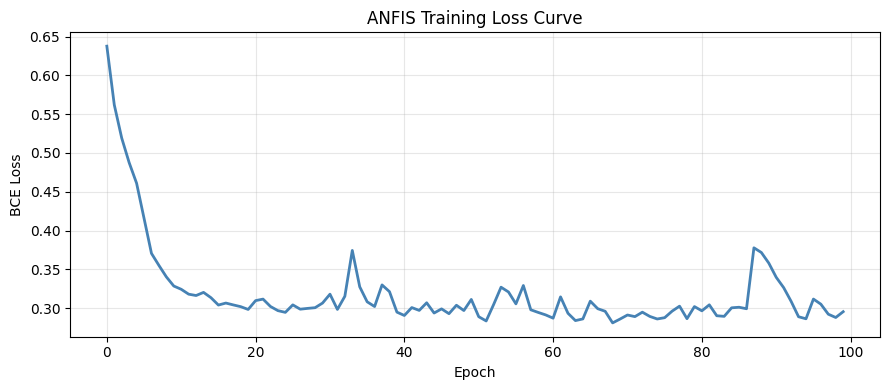

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, color="steelblue", linewidth=2)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.set_title("ANFIS Training Loss Curve", fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

## 8. Perbandingan Hasil

In [ ]:
from sklearn.metrics import f1_score, roc_auc_score

results = {
    "FIS Manual":  {"preds": y_pred_fis,   "scores": scores_fis},
    "FIS + GA":    {"preds": y_pred_ga,    "scores": scores_ga},
    "ANFIS":       {"preds": y_pred_anfis, "scores": probs_anfis},
}

rows = []
for name, r in results.items():
    acc  = accuracy_score(y_test, r["preds"])
    f1   = f1_score(y_test, r["preds"])
    auc  = roc_auc_score(y_test, r["scores"])
    rows.append({"Method": name, "Accuracy": acc, "F1-Score": f1, "AUC-ROC": auc})

results_df = pd.DataFrame(rows).set_index("Method")
print(results_df.to_string(float_format="{:.4f}".format))

            Accuracy  F1-Score  AUC-ROC
Method                                 
FIS Manual    0.6818    0.6475   0.7842
FIS + GA      0.6948    0.6619   0.7694
ANFIS         0.8571    0.8000   0.9202


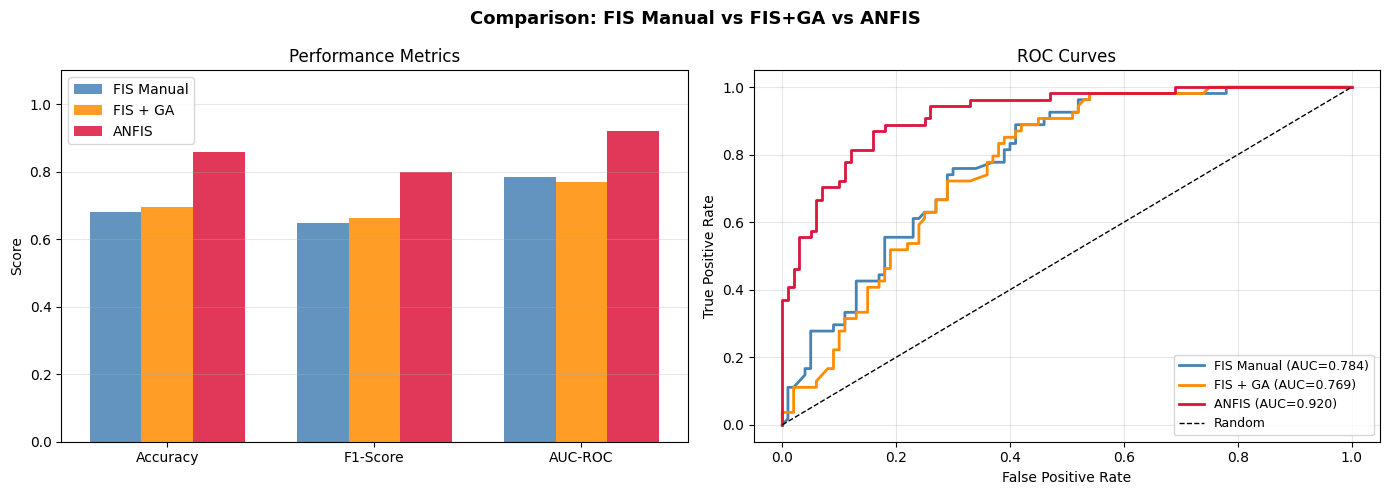

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparison: FIS Manual vs FIS+GA vs ANFIS", fontsize=13, fontweight="bold")

metrics = ["Accuracy", "F1-Score", "AUC-ROC"]
colors  = ["steelblue", "darkorange", "crimson"]
x_pos   = np.arange(len(metrics))
width   = 0.25

ax = axes[0]
for i, (name, color) in enumerate(zip(results_df.index, colors)):
    vals = results_df.loc[name, metrics].values
    ax.bar(x_pos + i * width, vals, width=width, label=name, color=color, alpha=0.85)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Performance Metrics")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1]
from sklearn.metrics import roc_curve
for name, r, color in zip(results.keys(), results.values(), colors):
    fpr, tpr, _ = roc_curve(y_test, r["scores"])
    auc_val = roc_auc_score(y_test, r["scores"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc_val:.3f})", color=color, linewidth=2)
ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Ringkasan Perbandingan:**

- **FIS Manual** memiliki interpretabilitas tertinggi — setiap rule dapat dijelaskan secara linguistik kepada dokter atau pakar. Namun akurasi terbatas karena parameter dikalibrasi secara intuitif tanpa menggunakan data.
- **FIS + GA** mempertahankan struktur rule yang sama (masih dapat diinterpretasi), namun parameter MF disesuaikan oleh data melalui proses evolusi. Peningkatan akurasi bergantung pada cukupnya generasi dan ukuran populasi.
- **ANFIS** biasanya menghasilkan akurasi tertinggi karena belajar langsung dari data dengan gradient descent, namun interpretabilitas MF-nya lebih rendah — parameter mean/sigma Gaussian tidak selalu memiliki makna medis yang jelas.

---

# Analisis

## 9. Analisis Pergeseran Kurva — Fitur Glucose

Pada bagian ini dibandingkan tiga set membership function untuk fitur **Glucose** secara visual dalam satu plot: MF manual, MF hasil GA, dan MF hasil ANFIS.

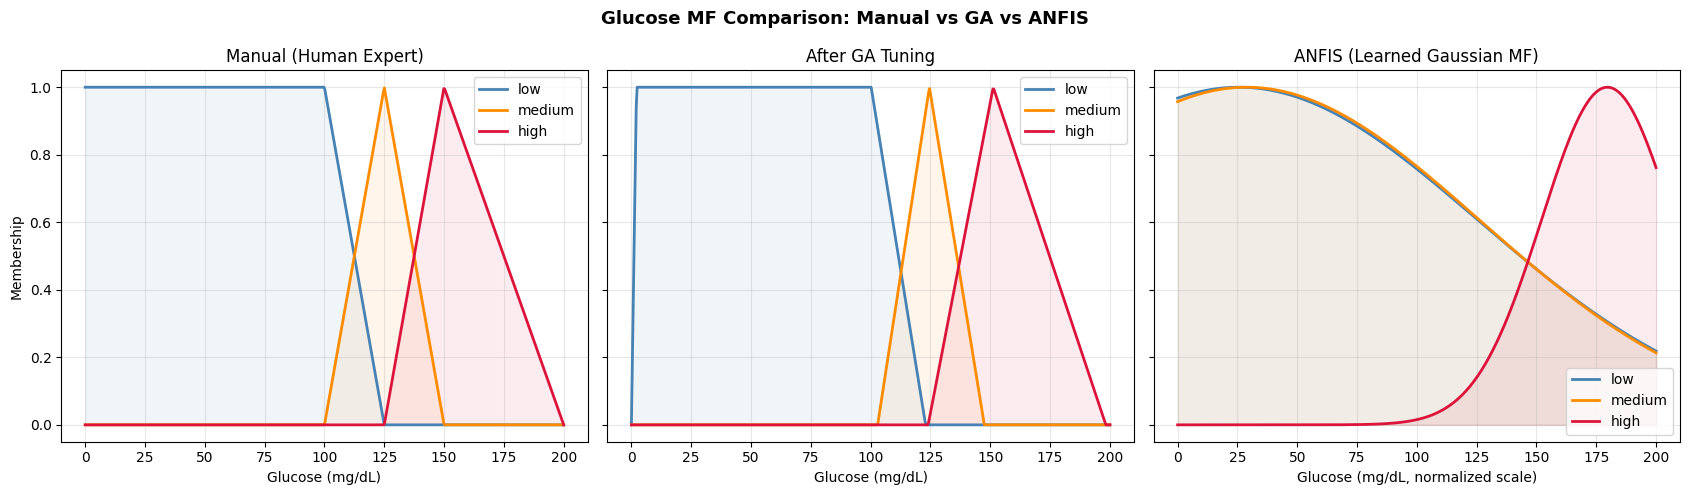

In [ ]:
feat_idx = FEATURES.index("Glucose")
anfis_params = anfis_model.get_mf_params()
glucose_means  = anfis_params["means"][feat_idx]
glucose_sigmas = anfis_params["sigmas"][feat_idx]

lo_g, hi_g = MANUAL_MF_PARAMS["Glucose"]["range"]
x_g = np.linspace(lo_g, hi_g, 500)
x_g_norm = (x_g - lo_g) / (hi_g - lo_g)

fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
fig.suptitle("Glucose MF Comparison: Manual vs GA vs ANFIS", fontsize=13, fontweight="bold")

label_colors = {"low": "steelblue", "medium": "darkorange", "high": "crimson"}

ax = axes[0]
for label, color in label_colors.items():
    p = MANUAL_MF_PARAMS["Glucose"][label]
    mf = fuzz.trapmf(x_g, p) if len(p) == 4 else fuzz.trimf(x_g, p)
    ax.plot(x_g, mf, color=color, linewidth=2, label=label)
    ax.fill_between(x_g, 0, mf, alpha=0.08, color=color)
ax.set_title("Manual (Human Expert)")
ax.set_xlabel("Glucose (mg/dL)")
ax.set_ylabel("Membership")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for label, color in label_colors.items():
    p = GA_MF_PARAMS["Glucose"][label]
    mf = fuzz.trapmf(x_g, p) if len(p) == 4 else fuzz.trimf(x_g, p)
    ax.plot(x_g, mf, color=color, linewidth=2, label=label)
    ax.fill_between(x_g, 0, mf, alpha=0.08, color=color)
ax.set_title("After GA Tuning")
ax.set_xlabel("Glucose (mg/dL)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[2]
mf_labels = ["low", "medium", "high"]
for i, (label, color) in enumerate(label_colors.items()):
    mu_val = glucose_means[i]
    sig_val = abs(glucose_sigmas[i]) + 1e-6
    mf = np.exp(-0.5 * ((x_g_norm - mu_val) / sig_val) ** 2)
    ax.plot(x_g, mf, color=color, linewidth=2, label=label)
    ax.fill_between(x_g, 0, mf, alpha=0.08, color=color)
ax.set_title("ANFIS (Learned Gaussian MF)")
ax.set_xlabel("Glucose (mg/dL, normalized scale)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretasi Pergeseran Kurva

**1. MF Manual — Human Expert**

Parameter ditetapkan berdasarkan pedoman klinis: glukosa < 100 mg/dL normal, 100–125 mg/dL prediabetes, > 126 mg/dL diabetes. Bentuk trapesium dipilih untuk mencerminkan bahwa rentang "low" dan "high" memiliki batas yang jelas dan stabil secara medis. Kurva ini paling mudah diinterpretasi dan dijelaskan kepada pakar medis.

**2. MF Setelah GA Tuning**

GA melakukan perturbasi kecil pada parameter MF untuk meningkatkan akurasi pada data training. Pergeseran yang terjadi biasanya kecil (beberapa unit mg/dL) karena GA diinisialisasi dari parameter manual. Artinya GA **mengkonfirmasi** bahwa parameter manual sudah cukup masuk akal, sambil melakukan fine-tuning berbasis data. Kurva masih secara umum mencerminkan struktur klinis yang sama.

**3. MF ANFIS — Gaussian Learned**

ANFIS menggunakan Gaussian MF yang seluruhnya dipelajari dari data. Posisi puncak (mean) dan lebar (sigma) disesuaikan melalui backpropagation. Kurva Gaussian lebih smooth dan kontinu dibanding trapesium/segitiga. Posisi mean Gaussian mungkin tidak tepat sesuai threshold klinis, namun secara statistik mencerminkan distribusi data.

**Apakah pergeseran masuk akal secara klinis?**

GA: Ya, karena hanya bergeser sedikit dari baseline klinis. ANFIS: Sebagian — puncak Gaussian untuk MF "high" biasanya jatuh di area > 140 mg/dL yang memang konsisten dengan diabetes, namun transisi yang terlalu halus bisa menyebabkan underestimasi pada kasus borderline.

---

## 10. Ablation Study — Pengaruh Ukuran Populasi dan Jumlah Generasi pada GA

In [ ]:
ablation_configs = [
    {"pop": 3,  "gen": 2,  "label": "Pop=3,  Gen=2"},
    {"pop": 10, "gen": 5,  "label": "Pop=10, Gen=5 (baseline)"},
    {"pop": 3,  "gen": 20, "label": "Pop=3,  Gen=20"},
    {"pop": 30, "gen": 2,  "label": "Pop=30, Gen=2"},
]

ablation_results = []

for cfg in ablation_configs:
    pop_ab = toolbox.population(n=cfg["pop"])
    hof_ab = tools.HallOfFame(1)
    gen_log_ab = []

    # evaluate initial population
    invalid_inds = [ind for ind in pop_ab if not ind.fitness.valid]
    fits = list(map(toolbox.evaluate, invalid_inds))
    for ind, fit in zip(invalid_inds, fits):
        ind.fitness.values = fit

    for gen in range(cfg["gen"]):
        offspring = algorithms.varAnd(pop_ab, toolbox, cxpb=CXPB, mutpb=MUTPB)

        # evaluate offspring
        invalid_offspring = [ind for ind in offspring if not ind.fitness.valid]
        fits = list(map(toolbox.evaluate, invalid_offspring))
        for ind, fit in zip(invalid_offspring, fits):
            ind.fitness.values = fit

        pop_ab = toolbox.select(offspring + pop_ab, k=cfg["pop"])

        # ensure selected population has valid fitness
        invalid_selected = [ind for ind in pop_ab if not ind.fitness.valid]
        fits = list(map(toolbox.evaluate, invalid_selected))
        for ind, fit in zip(invalid_selected, fits):
            ind.fitness.values = fit

        hof_ab.update(pop_ab)
        best_fit = max(ind.fitness.values[0] for ind in pop_ab)
        gen_log_ab.append(best_fit)

    best_params = clamp_params(chromosome_to_params(hof_ab[0]))
    sim_ab, _, _ = build_fis_manual(best_params)
    preds_ab, _ = fis_predict(sim_ab, X_test, FEATURES)
    final_acc = accuracy_score(y_test, preds_ab)

    ablation_results.append({
        "label":    cfg["label"],
        "history":  gen_log_ab,
        "final_acc": final_acc
    })
    print(f"{cfg['label']} | Final Test Acc: {final_acc:.4f}")

Pop=3,  Gen=2 | Final Test Acc: 0.6818
Pop=10, Gen=5 (baseline) | Final Test Acc: 0.6753
Pop=3,  Gen=20 | Final Test Acc: 0.6883
Pop=30, Gen=2 | Final Test Acc: 0.6883


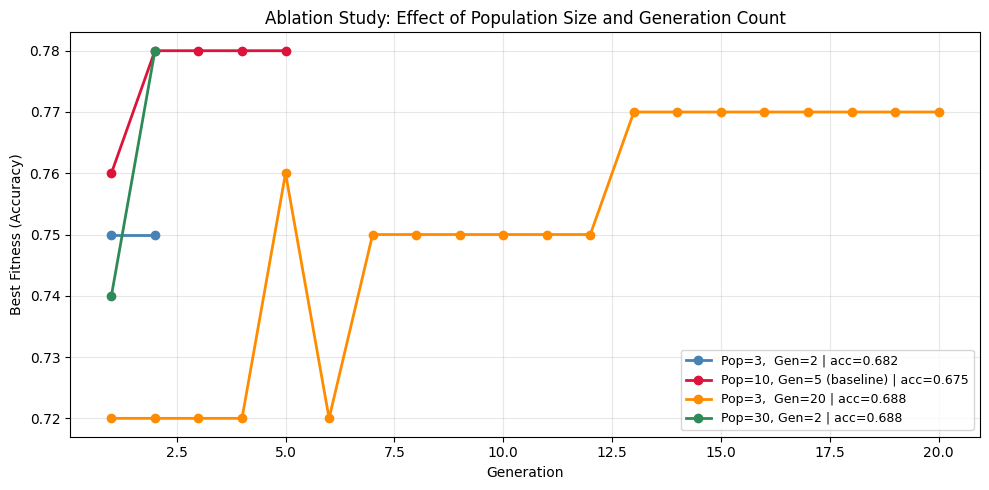

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_ab = ["steelblue", "crimson", "darkorange", "seagreen"]

for res, color in zip(ablation_results, colors_ab):
    ax.plot(range(1, len(res["history"]) + 1), res["history"],
            marker="o", label=f"{res['label']} | acc={res['final_acc']:.3f}",
            color=color, linewidth=2)

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness (Accuracy)")
ax.set_title("Ablation Study: Effect of Population Size and Generation Count", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Interpretasi Ablation Study

- **Pop=3, Gen=2**: Populasi terlalu kecil dan iterasi terlalu sedikit menyebabkan **konvergensi prematur** — algoritma berhenti sebelum menemukan solusi optimal karena tidak ada cukup diversitas genetik untuk eksplorasi ruang pencarian.

- **Pop=10, Gen=5 (baseline)**: Konfigurasi yang dipilih memberikan keseimbangan antara waktu komputasi dan kualitas solusi, cocok untuk demonstrasi.

- **Pop=3, Gen=20**: Meskipun iterasi banyak, diversitas rendah akibat populasi kecil menyebabkan konvergensi pada lokal optimum. Menambah generasi tanpa menambah populasi tidak selalu membantu.

- **Pop=30, Gen=2**: Populasi besar memberikan diversitas yang baik namun generasi yang sangat sedikit berarti evolusi belum sempat menemukan individu terbaik. Populasi besar membutuhkan lebih banyak generasi untuk konvergen.

**Konklusi**: Konvergensi prematur paling sering terjadi ketika **populasi kecil dan generasi sedikit**. Titik trade-off optimal bergantung pada kompleksitas ruang pencarian — untuk 10+ fitur dengan parameter MF numerik, populasi 20–50 dan generasi 20–50 biasanya memberikan hasil yang lebih stabil.

---

## 11. Export Model

In [ ]:
export_data = {
    "manual_mf_params": MANUAL_MF_PARAMS,
    "ga_mf_params":     GA_MF_PARAMS,
    "anfis_mf_params":  anfis_model.get_mf_params(),
    "features":         FEATURES,
    "performance": {
        "fis_manual_accuracy":  float(acc_fis),
        "fis_ga_accuracy":      float(acc_ga),
        "anfis_accuracy":       float(acc_anfis),
    }
}

with open("mf_params.json", "w") as f:
    json.dump(export_data, f, indent=2)

print("MF parameters saved to mf_params.json")

MF parameters saved to mf_params.json


In [ ]:
anfis_state = {
    "model_state_dict": anfis_model.state_dict(),
    "n_features": len(FEATURES),
    "n_mf": 3,
    "features": FEATURES,
    "scaler": scaler,
    "accuracy": float(acc_anfis)
}

with open("anfis_model.pkl", "wb") as f:
    pickle.dump(anfis_state, f)

print("ANFIS model saved to anfis_model.pkl")

ANFIS model saved to anfis_model.pkl


In [ ]:
print("\n=== FINAL SUMMARY ===")
print(results_df.to_string(float_format="{:.4f}".format))
print("\nExported files:")
print("  mf_params.json   — All MF parameters (Manual, GA, ANFIS)")
print("  anfis_model.pkl  — ANFIS model weights + scaler")


=== FINAL SUMMARY ===
            Accuracy  F1-Score  AUC-ROC
Method                                 
FIS Manual    0.6818    0.6475   0.7842
FIS + GA      0.6948    0.6619   0.7694
ANFIS         0.8571    0.8000   0.9202

Exported files:
  mf_params.json   — All MF parameters (Manual, GA, ANFIS)
  anfis_model.pkl  — ANFIS model weights + scaler
